# Interactive Denoising Lab — PandaOmron

Experiment with GR00T N1.6's flow-matching denoising loop using
`ROBOCASA_PANDA_OMRON` observations captured from the simulator.

PandaOmron uses **EEF delta** actions, so the 3D plots show true Cartesian
end-effector trajectories.

## Prerequisites

Before running this notebook, capture at least one observation `.npz` file
using `interactive_rollout.py`:

```bash
# Terminal 1 (model venv)
uv run python gr00t/eval/run_gr00t_server.py \
  --model-path nvidia/GR00T-N1.6-3B \
  --embodiment-tag ROBOCASA_PANDA_OMRON \
  --use-sim-policy-wrapper

# Terminal 2 (sim venv)
gr00t/eval/sim/robocasa/robocasa_uv/.venv/bin/python \
  scripts/denoising_lab/interactive_rollout.py \
  --env-name robocasa_panda_omron/OpenDrawer_PandaOmron_Env \
  --host 127.0.0.1 --port 5555 \
  --n-action-steps 8 --max-episode-steps 720 \
  --save-dir /tmp/saved_observations
```

Then press `o` in the interactive rollout to save an observation, and set
`OBS_PATH` below to the saved `.npz` file.

In [1]:
# Cell 1: Imports + config
import sys, os
import numpy as np
import torch
import matplotlib.pyplot as plt

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from scripts.denoising_lab.denoising_lab import (
    DenoisingLab, TrajectoryVisualizer, compare_strategies,
)

MODEL_PATH = "nvidia/GR00T-N1.6-3B"
EMBODIMENT_TAG = "robocasa_panda_omron"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Path to observation .npz captured by interactive_rollout.py
OBS_PATH = "/tmp/saved_observations/ep000_step001.npz"

print(f"Device: {DEVICE}")

/home/ubuntu/my_Isaac-GR00T/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


In [2]:
# Cell 2: Load model
lab = DenoisingLab(MODEL_PATH, EMBODIMENT_TAG, device=DEVICE)
print(f"Model loaded. Action horizon: {lab.action_horizon}, Action dim: {lab.action_dim}")
print(f"Inference timesteps: {lab.num_inference_timesteps}, Timestep buckets: {lab.num_timestep_buckets}")

/usr/bin/ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status
/usr/bin/ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status
/home/ubuntu/my_Isaac-GR00T/.venv/lib/python3.10/site-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.18). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


Tune backbone llm: False
Tune backbone visual: False
Backbone trainable parameter: model.language_model.model.layers.12.self_attn.q_proj.weight
Backbone trainable parameter: model.language_model.model.layers.12.self_attn.k_proj.weight
Backbone trainable parameter: model.language_model.model.layers.12.self_attn.v_proj.weight
Backbone trainable parameter: model.language_model.model.layers.12.self_attn.o_proj.weight
Backbone trainable parameter: model.language_model.model.layers.12.self_attn.q_norm.weight
Backbone trainable parameter: model.language_model.model.layers.12.self_attn.k_norm.weight
Backbone trainable parameter: model.language_model.model.layers.12.mlp.gate_proj.weight
Backbone trainable parameter: model.language_model.model.layers.12.mlp.up_proj.weight
Backbone trainable parameter: model.language_model.model.layers.12.mlp.down_proj.weight
Backbone trainable parameter: model.language_model.model.layers.12.input_layernorm.weight
Backbone trainable parameter: model.language_mode

/home/ubuntu/my_Isaac-GR00T/gr00t/model/modules/dit.py:205: FutureWarning: Accessing config attribute `compute_dtype` directly via 'AlternateVLDiT' object attribute is deprecated. Please access 'compute_dtype' over 'AlternateVLDiT's config object instead, e.g. 'unet.config.compute_dtype'.
  embedding_dim=self.inner_dim, compute_dtype=self.compute_dtype
/home/ubuntu/my_Isaac-GR00T/gr00t/model/modules/dit.py:236: FutureWarning: Accessing config attribute `output_dim` directly via 'AlternateVLDiT' object attribute is deprecated. Please access 'output_dim' over 'AlternateVLDiT's config object instead, e.g. 'unet.config.output_dim'.
  self.proj_out_2 = nn.Linear(self.inner_dim, self.output_dim)


Tune action head projector: True
Tune action head diffusion model: True
Tune action head vlln: True


`use_fast` is set to `True` but the image processor class does not have a fast version.  Falling back to the slow version.
Loading checkpoint shards: 100%|██████████| 2/2 [00:04<00:00,  2.26s/it]


Model loaded. Action horizon: 50, Action dim: 128
Inference timesteps: 4, Timestep buckets: 1000


In [3]:
# Cell 3: Load observation from .npz saved by interactive_rollout.py
obs = DenoisingLab.load_observation(OBS_PATH)
print("Observation loaded from:", OBS_PATH)
print("Keys:", list(obs.keys()))
for k, v in obs.items():
    if isinstance(v, np.ndarray):
        print(f"  {k}: shape={v.shape}, dtype={v.dtype}")
    else:
        print(f"  {k}: {v}")

Observation loaded from: /tmp/saved_observations/ep000_step001.npz
Keys: ['state.base_position', 'state.base_rotation', 'state.end_effector_position_absolute', 'state.end_effector_position_relative', 'state.end_effector_rotation_absolute', 'state.end_effector_rotation_relative', 'state.gripper_qpos', 'state.gripper_qvel', 'state.joint_position', 'state.joint_position_cos', 'state.joint_position_sin', 'state.joint_velocity', 'video.res256_image_side_0', 'video.res256_image_side_1', 'video.res256_image_wrist_0', 'video.res512_image_side_0', 'video.res512_image_side_1', 'video.res512_image_wrist_0', 'annotation.human.action.task_description']
  state.base_position: shape=(1, 1, 3), dtype=float32
  state.base_rotation: shape=(1, 1, 4), dtype=float32
  state.end_effector_position_absolute: shape=(1, 1, 3), dtype=float32
  state.end_effector_position_relative: shape=(1, 1, 3), dtype=float32
  state.end_effector_rotation_absolute: shape=(1, 1, 4), dtype=float32
  state.end_effector_rotation_r

In [ ]:
# Cell 3b: Visualize camera views from the saved observation
# Shows what the robot sees — helps identify which .npz to experiment with
fig = DenoisingLab.plot_camera_views(obs, figsize=(14, 4))
plt.suptitle(f"Camera views — {OBS_PATH.split('/')[-1]}", fontsize=12)
plt.show()

In [4]:
# Cell 4: Encode backbone features (EXPENSIVE — run once)
features = lab.encode_features_from_sim_obs(obs)
print(f"Backbone features: {features.backbone_features.shape}")
print(f"State features: {features.state_features.shape}")
print(f"Embodiment ID: {features.embodiment_id}")

Backbone features: torch.Size([1, 284, 2048])
State features: torch.Size([1, 1, 1536])
Embodiment ID: tensor([13], device='cuda:0')


In [5]:
# Cell 5: Default denoising (4-step flow matching)
result = lab.denoise(features, seed=42)
print(f"Final action shape: {result.action_pred.shape}")
print(f"Seed: {result.seed}")
for info in result.intermediates:
    print(f"  Step {info.step}: t_cont={info.t_cont:.3f} t_disc={info.t_discretized} "
          f"action_norm={info.action_norm:.4f} velocity_norm={info.velocity_norm:.4f}")

Final action shape: torch.Size([1, 50, 128])
Seed: 42
  Step 0: t_cont=0.000 t_disc=0 action_norm=77.7980 velocity_norm=31.3307
  Step 1: t_cont=0.250 t_disc=250 action_norm=77.2682 velocity_norm=31.9305
  Step 2: t_cont=0.500 t_disc=500 action_norm=77.6256 velocity_norm=32.6070
  Step 3: t_cont=0.750 t_disc=750 action_norm=78.9122 velocity_norm=33.4281


In [6]:
# Cell 6: Decode + inspect actions
decoded = lab.decode_raw_actions(result.action_pred, features.states)
print("Decoded action keys (PandaOmron EEF):")
for key, arr in decoded.items():
    print(f"  {key}: shape={arr.shape}")

for t in range(min(3, list(decoded.values())[0].shape[1])):
    print(lab.label_action_step(decoded, t))

Decoded action keys (PandaOmron EEF):
  end_effector_position: shape=(1, 16, 3)
  end_effector_rotation: shape=(1, 16, 3)
  gripper_close: shape=(1, 16, 1)
  base_motion: shape=(1, 16, 4)
  control_mode: shape=(1, 16, 1)
Step 0:
  end_effector_position: [-0.2490 +0.0352 -0.0815]
  end_effector_rotation: [-0.0010 -0.0410 -0.0049]
  gripper_close: [+0.0020]
  base_motion: [+0.0000 +0.0000 +0.0000 +0.0000]
  control_mode: [+0.0000]
Step 1:
  end_effector_position: [-0.2578 +0.0918 -0.0552]
  end_effector_rotation: [-0.0039 -0.0254 -0.0254]
  gripper_close: [+0.0000]
  base_motion: [+0.0000 +0.0000 +0.0000 +0.0000]
  control_mode: [+0.0000]
Step 2:
  end_effector_position: [-0.3203 +0.0684 -0.0330]
  end_effector_rotation: [-0.0254 -0.0498 -0.0254]
  gripper_close: [+0.0039]
  base_motion: [+0.0000 +0.0000 +0.0000 +0.0000]
  control_mode: [+0.0000]


Plotting EEF trajectory using key: 'end_effector_position'


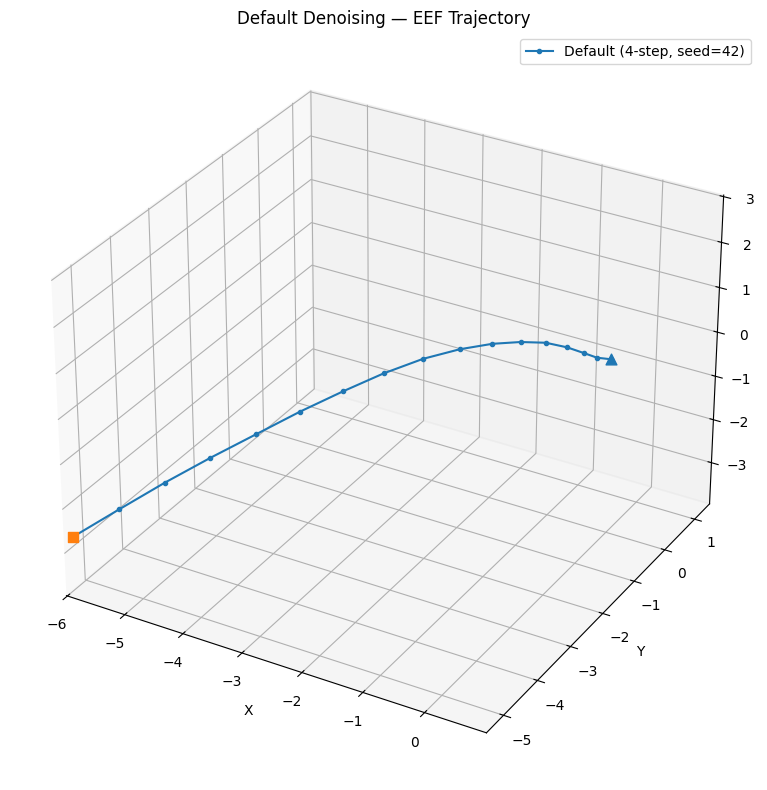

In [16]:
# Cell 7: 3D EEF trajectory plot
EEF_KEY = "end_effector_position"
print(f"Plotting EEF trajectory using key: '{EEF_KEY}'")

viz = TrajectoryVisualizer()
viz.add_trajectory(decoded, "Default (4-step, seed=42)", eef_key=EEF_KEY)
fig = viz.plot_eef_3d(title="Default Denoising — EEF Trajectory")
plt.show()

In [ ]:
# Cell 7b: 3D EEF trajectory with orientation frames and gripper state
# Same trajectory as above, but with mini RGB coordinate frames (R=X, G=Y,
# B=Z) showing accumulated EEF orientation from axis-angle deltas, and
# green→red coloured markers for gripper state (green=open, red=closed).
#
# Toggle show_orientation / show_gripper to enable/disable independently.
# frame_stride controls how often orientation frames are drawn (1=every step).

viz_full = TrajectoryVisualizer()
viz_full.add_trajectory(decoded, "Default (4-step, seed=42)", eef_key=EEF_KEY)

fig = viz_full.plot_eef_3d(
    title="EEF Trajectory — Orientation & Gripper",
    show_orientation=True,
    show_gripper=True,
)
plt.show()

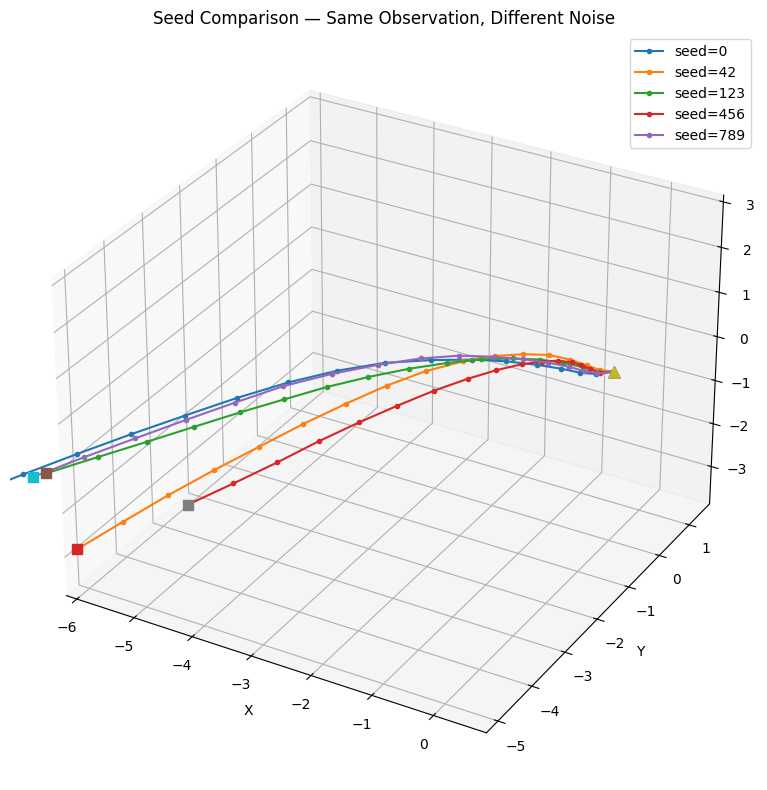

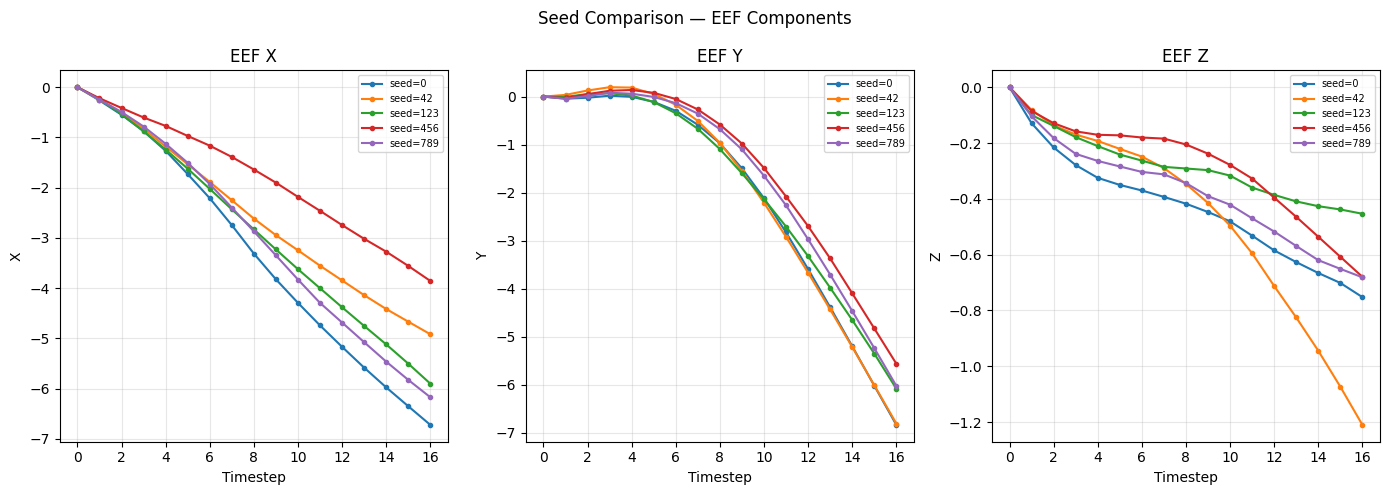

In [17]:
# Cell 8: Compare seeds — 5 different seeds on the same 3D plot
viz_seeds = TrajectoryVisualizer()
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]

for i, seed in enumerate([0, 42, 123, 456, 789]):
    r = lab.denoise(features, seed=seed)
    d = lab.decode_raw_actions(r.action_pred, features.states)
    viz_seeds.add_trajectory(d, f"seed={seed}", color=colors[i], eef_key=EEF_KEY)

fig = viz_seeds.plot_eef_3d(title="Seed Comparison — Same Observation, Different Noise")
plt.show()

fig2 = viz_seeds.plot_eef_components(title="Seed Comparison — EEF Components")
plt.show()

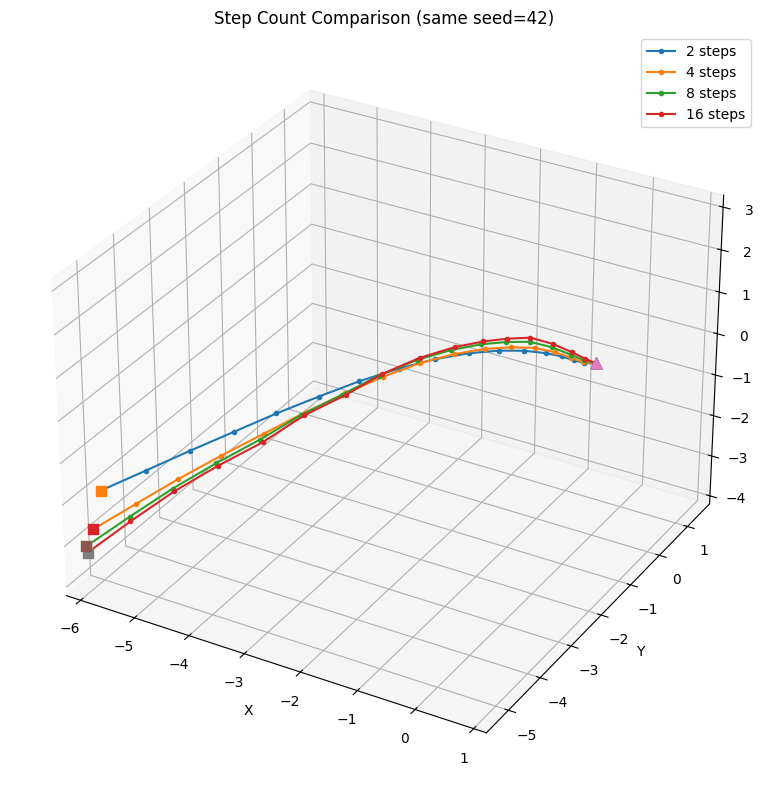

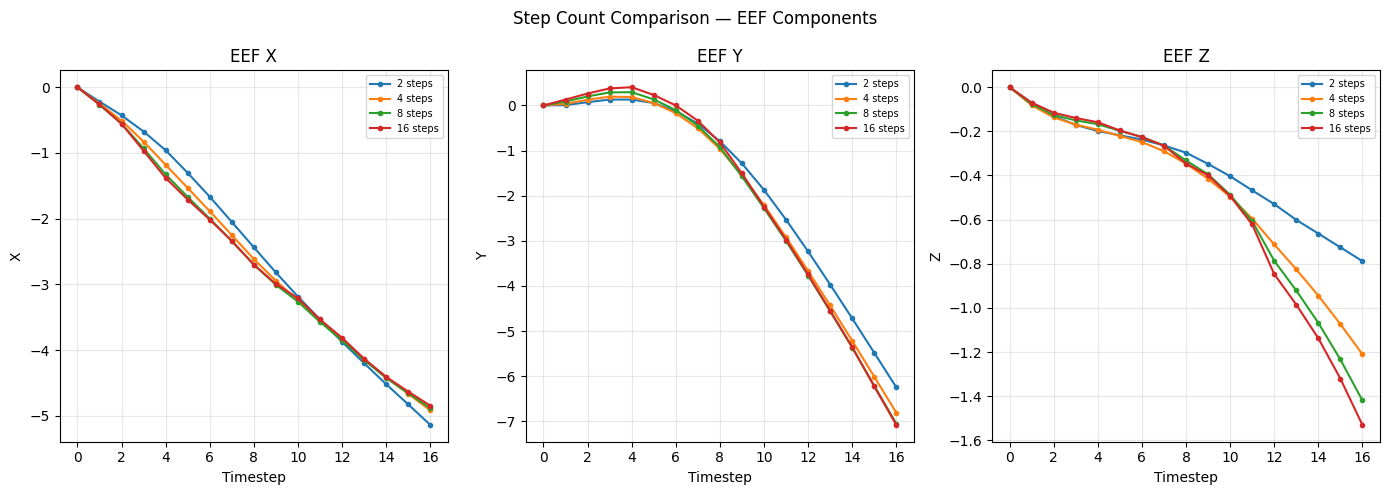

In [18]:
# Cell 9: Compare step counts — 2/4/8/16 denoising steps
strategies = [
    {"num_steps": 2, "seed": 42},
    {"num_steps": 4, "seed": 42},
    {"num_steps": 8, "seed": 42},
    {"num_steps": 16, "seed": 42},
]
labels = ["2 steps", "4 steps", "8 steps", "16 steps"]

results, viz_steps = compare_strategies(lab, features, strategies, labels, eef_key=EEF_KEY)

fig = viz_steps.plot_eef_3d(title="Step Count Comparison (same seed=42)")
plt.show()

fig2 = viz_steps.plot_eef_components(title="Step Count Comparison — EEF Components")
plt.show()

In [19]:
# Cell 10: Manual step-by-step denoising
gen = torch.Generator(device=lab.device).manual_seed(42)
actions = torch.randn(
    (1, lab.action_horizon, lab.action_dim),
    dtype=lab.dtype, device=lab.device, generator=gen,
)

num_steps = 4
print(f"Starting manual {num_steps}-step denoising...")
print(f"Initial noise norm: {actions.float().norm().item():.4f}")

for step in range(num_steps):
    velocity, actions = lab.denoise_single_step(features, actions, step, num_steps)
    print(f"  Step {step}: action_norm={actions.float().norm().item():.4f} "
          f"velocity_norm={velocity.float().norm().item():.4f}")

manual_decoded = lab.decode_raw_actions(actions, features.states)
print("\nManual denoising complete. Decoded keys:", list(manual_decoded.keys()))

Starting manual 4-step denoising...
Initial noise norm: 79.1332
  Step 0: action_norm=77.7980 velocity_norm=31.3307
  Step 1: action_norm=77.2682 velocity_norm=31.9305
  Step 2: action_norm=77.6256 velocity_norm=32.6070
  Step 3: action_norm=78.9122 velocity_norm=33.4281

Manual denoising complete. Decoded keys: ['end_effector_position', 'end_effector_rotation', 'gripper_close', 'base_motion', 'control_mode']


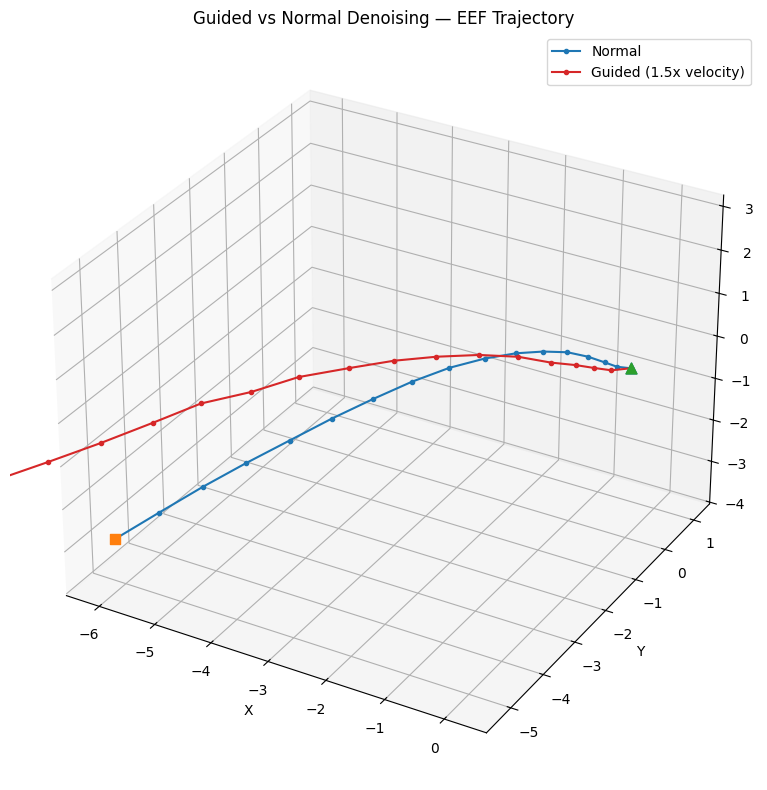

In [20]:
# Cell 11: Guided denoising — scale velocity by 1.5x
from functools import partial

def scale_velocity(actions, step_idx, velocity, scale=1.5):
    return velocity * scale

result_guided = lab.denoise(features, seed=42, guided_fn=partial(scale_velocity, scale=1.5))
result_normal = lab.denoise(features, seed=42)

viz_guide = TrajectoryVisualizer()
d_normal = lab.decode_raw_actions(result_normal.action_pred, features.states)
d_guided = lab.decode_raw_actions(result_guided.action_pred, features.states)

viz_guide.add_trajectory(d_normal, "Normal", color="tab:blue", eef_key=EEF_KEY)
viz_guide.add_trajectory(d_guided, "Guided (1.5x velocity)", color="tab:red", eef_key=EEF_KEY)

fig = viz_guide.plot_eef_3d(title="Guided vs Normal Denoising — EEF Trajectory")
plt.show()

In [21]:
# Cell 12: Raw denoising loop — full playground mode
seed = 42
num_steps = 4
dt = 1.0 / num_steps

vl_embeds = features.backbone_features
state_feats = features.state_features
emb_id = features.embodiment_id
bb_output = features.backbone_output
B = vl_embeds.shape[0]
device = vl_embeds.device

gen = torch.Generator(device=device).manual_seed(seed)
actions = torch.randn(
    (B, lab.action_horizon, lab.action_dim),
    dtype=vl_embeds.dtype, device=device, generator=gen,
)

with torch.inference_mode():
    for t in range(num_steps):
        t_cont = t / float(num_steps)
        t_disc = int(t_cont * lab.num_timestep_buckets)

        ts = torch.full((B,), t_disc, device=device)
        act_feat = lab.action_head.action_encoder(actions, ts, emb_id)

        if lab.action_head.config.add_pos_embed:
            pos = torch.arange(act_feat.shape[1], dtype=torch.long, device=device)
            act_feat = act_feat + lab.action_head.position_embedding(pos).unsqueeze(0)

        sa = torch.cat((state_feats, act_feat), dim=1)

        if lab.action_head.config.use_alternate_vl_dit:
            out = lab.action_head.model(
                hidden_states=sa, encoder_hidden_states=vl_embeds, timestep=ts,
                image_mask=bb_output.image_mask,
                backbone_attention_mask=bb_output.backbone_attention_mask,
            )
        else:
            out = lab.action_head.model(
                hidden_states=sa, encoder_hidden_states=vl_embeds, timestep=ts,
            )

        pred = lab.action_head.action_decoder(out, emb_id)
        velocity = pred[:, -lab.action_horizon:]

        # === EDIT HERE: modify velocity, inject guidance, etc. ===
        # velocity = velocity * 1.0  # no-op example

        actions = actions + dt * velocity
        print(f"Step {t}: action_norm={actions.float().norm():.4f} vel_norm={velocity.float().norm():.4f}")

raw_decoded = lab.decode_raw_actions(actions, features.states)
print("\nDone. Decoded keys:", list(raw_decoded.keys()))

Step 0: action_norm=77.7980 vel_norm=31.3307
Step 1: action_norm=77.2682 vel_norm=31.9305
Step 2: action_norm=77.6256 vel_norm=32.6070
Step 3: action_norm=78.9122 vel_norm=33.4281

Done. Decoded keys: ['end_effector_position', 'end_effector_rotation', 'gripper_close', 'base_motion', 'control_mode']


In [ ]:
# Cell 13: Denoising progression visualization
result_for_prog = lab.denoise(features, seed=42)
fig = viz.plot_denoising_progression(result_for_prog, lab, eef_key=EEF_KEY)
plt.show()

In [ ]:
# Cell 14: Export action chunk for replay in the simulator
#
# After experimenting with denoising strategies above, save your preferred
# action chunk for replay. Then run in the sim venv:
#
#   gr00t/eval/sim/robocasa/robocasa_uv/.venv/bin/python \
#     scripts/denoising_lab/interactive_rollout.py \
#     --replay \
#     --env-name robocasa_panda_omron/OpenDrawer_PandaOmron_Env \
#     --obs-path /tmp/saved_observations/ep000_step001.npz \
#     --action-path /tmp/action_chunks/default_seed42.npz \
#     --video-out /tmp/replay_default.mp4

EXPORT_DIR = "/tmp/action_chunks"
os.makedirs(EXPORT_DIR, exist_ok=True)

# Export the default result (from cell 5)
export_path = os.path.join(EXPORT_DIR, "default_seed42.npz")
DenoisingLab.save_action_chunk(decoded, export_path)
print(f"Action chunk saved to: {export_path}")
print("Action keys:", list(decoded.keys()))
for k, v in decoded.items():
    print(f"  {k}: shape={v.shape}")